In [1]:
from google.colab import files
uploaded = files.upload()

Saving cleaned_sales_data (2).csv to cleaned_sales_data (2).csv


In [3]:
import pandas as pd
df = pd.read_csv("cleaned_sales_data (2).csv")

In [ ]:
df.head()

,Transaction ID,Category,Item,Price Per Unit,Quantity,Total Spent,Transaction Date,Discount Applied,Total Revenue,Location
0,TXN_6867343,Patisserie,Item_10_PAT,18.5,10.0,185.0,2024-04-08,1.0,10.0,Bangalore
1,TXN_3731986,Milk Products,Item_17_MILK,29.0,9.0,261.0,2023-07-23,1.0,9.0,Chennai
2,TXN_9303719,Butchers,Item_12_BUT,21.5,2.0,43.0,2022-10-05,0.0,2.0,Chennai
3,TXN_4575373,Food,Item_6_FOOD,12.5,7.0,87.5,2022-10-02,0.0,7.0,Hyderabad
4,TXN_3652209,Food,Item_1_FOOD,5.0,8.0,40.0,2023-06-10,1.0,8.0,Mumbai


In [4]:
df

,Transaction ID,Category,Item,Price Per Unit,Quantity,Total Spent,Transaction Date,Discount Applied,Total Revenue,Location
0,TXN_6867343,Patisserie,Item_10_PAT,18.5,10.0,185.0,2024-04-08,1.0,10.0,Bangalore
1,TXN_3731986,Milk Products,Item_17_MILK,29.0,9.0,261.0,2023-07-23,1.0,9.0,Chennai
2,TXN_9303719,Butchers,Item_12_BUT,21.5,2.0,43.0,2022-10-05,0.0,2.0,Chennai
3,TXN_4575373,Food,Item_6_FOOD,12.5,7.0,87.5,2022-10-02,0.0,7.0,Hyderabad
4,TXN_3652209,Food,Item_1_FOOD,5.0,8.0,40.0,2023-06-10,1.0,8.0,Mumbai
...,...,...,...,...,...,...,...,...,...,...
7574,TXN_6298574,Milk Products,Item_1_MILK,5.0,4.0,20.0,2023-05-09,0.0,4.0,Mumbai
7575,TXN_4890318,Butchers,Item_3_BUT,8.0,5.0,40.0,2023-03-28,0.0,5.0,Bangalore
7576,TXN_2318174,Patisserie,Item_1_PAT,5.0,9.0,45.0,2024-05-13,0.0,9.0,Chennai
7577,TXN_4009414,Beverages,Item_2_BEV,6.5,9.0,58.5,2022-08-12,0.0,9.0,Hyderabad


In [5]:
df.columns

Index(['Transaction ID', 'Category', 'Item', 'Price Per Unit', 'Quantity',
       'Total Spent', 'Transaction Date', 'Discount Applied', 'Total Revenue',
       'Location'],
      dtype='object')

In [6]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7579 entries, 0 to 7578
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    7579 non-null   object 
 1   Category          7579 non-null   object 
 2   Item              7579 non-null   object 
 3   Price Per Unit    7579 non-null   float64
 4   Quantity          7579 non-null   float64
 5   Total Spent       7579 non-null   float64
 6   Transaction Date  7579 non-null   object 
 7   Discount Applied  7579 non-null   float64
 8   Total Revenue     7579 non-null   float64
 9   Location          7579 non-null   object 
dtypes: float64(5), object(5)
memory usage: 592.2+ KB


,Price Per Unit,Quantity,Total Spent,Discount Applied,Total Revenue
count,7579.000000,7579.000000,7579.000000,7579.000000,7579.000000
mean,23.428882,5.557329,130.427893,0.501517,5.557329
std,10.704121,2.843546,94.378663,0.500031,2.843546
min,5.000000,1.000000,5.000000,0.000000,1.000000
25%,14.000000,3.000000,52.000000,0.000000,3.000000
50%,23.000000,6.000000,110.000000,1.000000,6.000000
75%,33.500000,8.000000,192.000000,1.000000,8.000000
max,41.000000,10.000000,410.000000,1.000000,10.000000


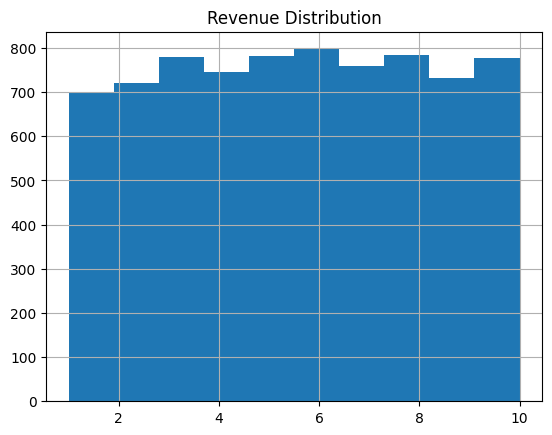

In [7]:
import matplotlib.pyplot as plt
df["Total Revenue"].hist()
plt.title("Revenue Distribution")
plt.show()

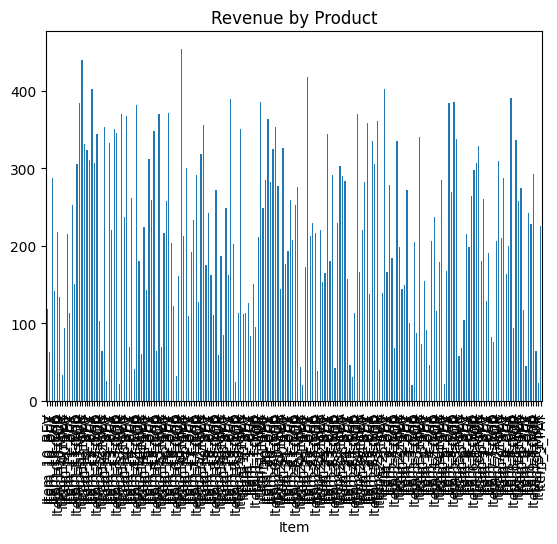

In [8]:
df.groupby("Item")["Total Revenue"].sum().plot(kind="bar")
plt.title("Revenue by Product")
plt.show()

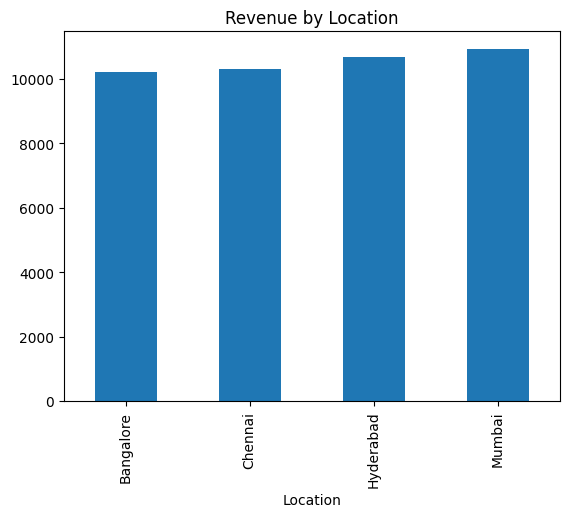

In [9]:
df.groupby("Location")["Total Revenue"].sum().plot(kind="bar")
plt.title("Revenue by Location")
plt.show()

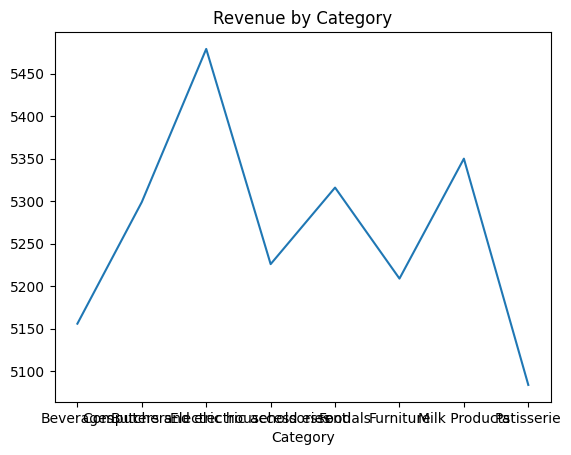

In [10]:
df.groupby("Category")["Total Revenue"].sum().plot(kind="line")
plt.title("Revenue by Category")
plt.show()

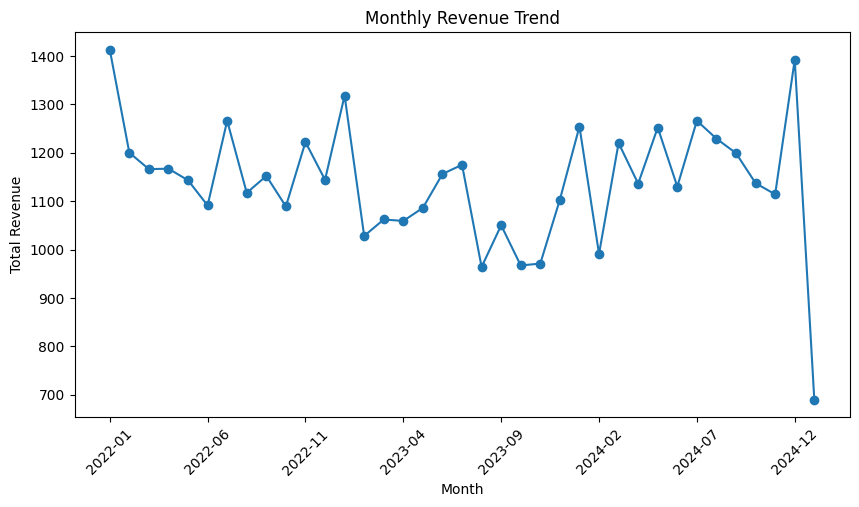

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert Transaction Date to datetime
df["Transaction Date"] = pd.to_datetime(df["Transaction Date"], format="%Y-%m-%d")

# Extract Month-Year for better clarity
df["Month"] = df["Transaction Date"].dt.to_period("M")

# Group by Month and calculate total revenue
monthly_revenue = df.groupby("Month")["Total Revenue"].sum()

# Convert period back to string for plotting
monthly_revenue.index = monthly_revenue.index.astype(str)

# Plot line chart
plt.figure(figsize=(10,5))
monthly_revenue.plot(kind="line", marker="o")

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.show()

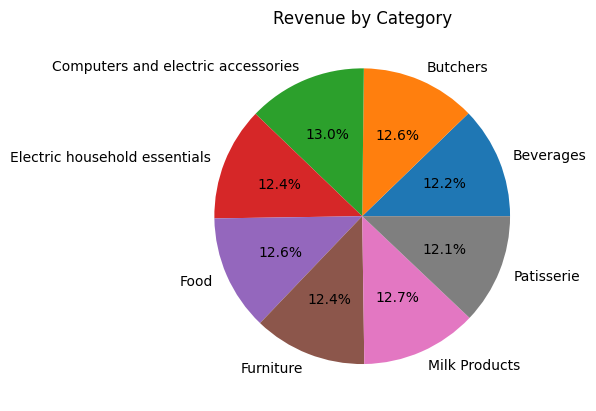

In [12]:
import matplotlib.pyplot as plt

# Group revenue by category
payment_revenue = df.groupby("Category")["Total Revenue"].sum()

# Create pie chart
plt.figure()
payment_revenue.plot(kind="pie", autopct='%1.1f%%')

plt.title("Revenue by Category")
plt.ylabel("")  # Remove default ylabel
plt.show()